# Topic analysis 

This notebook produces the analysis of the topics. 

In [6]:
import pandas as pd
import numpy as np
import math

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.cm as cm
import matplotlib.patches as mpatches

import geopandas as gpd

from collections import Counter

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

from umap import UMAP

from database.comments import Comments
from database.topics import Topics

import sys
sys.path.append('../functions')
from nlp_tasks import NLP_Tasks
from elastic_search_fncs import ElasticSearchFncs
import preprocessing_fncs as prep

nlp_tasks = NLP_Tasks()
esf = ElasticSearchFncs()
cs = Comments(env="dev")

Device set to use mps:0
Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.
Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


In [2]:
tp = Topics(env='dev')
tp_df = tp.read_all()

Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


In [3]:
tp_df

,id,comment_id,topic_number,probability,add_date
0,1,230384FUL_16,[],[],2025-10-21
1,2,21/3676/FUL_537,"[16, 0, 7]","[0.9496124818197162, 1.0, 0.532771282582039]",2025-10-21
2,3,21/03147/FUL_6,"[19, 0, 25]","[0.7651527090417625, 0.5496195083521116, 0.155...",2025-10-21
3,4,230384FUL_22,[47],[1.0],2025-10-21
4,5,230384FUL_15,[2],[1.0],2025-10-21
...,...,...,...,...,...
30325,30326,24/AP/2313_9,[37],[1.0],2025-10-21
30326,30327,241267FUL_81,[35],[1.0],2025-10-21
30327,30328,24/AP/2313_15,"[87, 44, 71, 72]","[0.13251934256196757, 0.0777459370777266, 0.07...",2025-10-21
30328,30329,24/AP/2313_17,"[25, 26]","[1.0, 0.7320134997496925]",2025-10-21


In [4]:
# bad_topics = {"bad":[0,11,27,32,38,51,57,89,98]}
# same_topics = {"parking":[1,16,28,31,41], 
#                "tree loss":[2,22,39], 
#                "out of character":[3,30], 
#                "too tall":[4,40],
#                "overdevelopment":[8,26,56],
#                "privacy":[10,35,42],
#                "public services":[12, 36],
#                "construction noise":[14,37,47]}

In [5]:
bad_topics = {"bad":[-1,0,10,16,31,39,41,42,56,57,88,98]}
same_topics = {"garden space":[1,43],
               "parking":[2,7,47], 
               "out of character":[3,36,40], 
               "too tall":[5,33],
               "conservation area":[8,35,48],
               "noise pollution":[11,38,46,49],
               "overdevelopment":[13,25],
               "traffic congestion":[18, 21]}

In [6]:
# Build a reverse mapping from each old topic → representative topic
topic_map = {}
for _, nums in same_topics.items():
    main = nums[0]
    for n in nums:
        topic_map[n] = main

tp_df['topic_number_updated'] = [[] for _ in range(len(tp_df))]
tp_df['probability_updated'] = [[] for _ in range(len(tp_df))]

for i in range(len(tp_df)):
    topics = tp_df.at[i, 'topic_number']
    probs = tp_df.at[i, 'probability']

    # filter out topics >= 50
    filtered = [(t, p) for t, p in zip(topics, probs) if t < 50]

    # filter out topics in bad_topics
    filtered = [(t, p) for t, p in filtered if all(t not in v for v in bad_topics.values())]

    # merge topics in same_topics
    merged = {}
    for t, p in filtered:
        new_t = topic_map.get(t, t)  # replace with main topic if part of a group
        merged[new_t] = merged.get(new_t, 0) + p  # sum probabilities

    # store results
    tp_df.at[i, 'topic_number_updated'] = list(merged.keys())
    tp_df.at[i, 'probability_updated'] = list(merged.values())

tp_df


,id,comment_id,topic_number,probability,add_date,topic_number_updated,probability_updated
0,1,230384FUL_16,[],[],2025-10-21,[],[]
1,2,21/3676/FUL_537,"[16, 0, 7]","[0.9496124818197162, 1.0, 0.532771282582039]",2025-10-21,[2],[0.532771282582039]
2,3,21/03147/FUL_6,"[19, 0, 25]","[0.7651527090417625, 0.5496195083521116, 0.155...",2025-10-21,"[19, 13]","[0.7651527090417625, 0.1552818674969217]"
3,4,230384FUL_22,[47],[1.0],2025-10-21,[2],[1.0]
4,5,230384FUL_15,[2],[1.0],2025-10-21,[2],[1.0]
...,...,...,...,...,...,...,...
30325,30326,24/AP/2313_9,[37],[1.0],2025-10-21,[37],[1.0]
30326,30327,241267FUL_81,[35],[1.0],2025-10-21,[8],[1.0]
30327,30328,24/AP/2313_15,"[87, 44, 71, 72]","[0.13251934256196757, 0.0777459370777266, 0.07...",2025-10-21,[44],[0.0777459370777266]
30328,30329,24/AP/2313_17,"[25, 26]","[1.0, 0.7320134997496925]",2025-10-21,"[13, 26]","[1.0, 0.7320134997496925]"


In [7]:
topic_names = pd.read_csv('../model_outputs/topic_model/bertopic_less_topics/object_topics.csv')

In [8]:
topic_names.head(10)

,Topic,Count,Name,Representation,MaximalMarginalRelevance,KeyBERTInspired,Representative_Docs,doc_1,doc_2,doc_3
0,-1,38355,-1_the_to_and_of,"['the', 'to', 'and', 'of', 'this', 'is', 'in',...","['the', 'to', 'and', 'of', 'this', 'is', 'in',...","['parking', 'space', 'traffic', 'road', 'impac...",['i object to this proposal on several grounds...,i object to this proposal on several grounds. ...,"firstly, i have been very concerned by the beh...",residents of are already surrounded on two sid...
1,0,14746,0_object_planning_application_following,"['object', 'planning', 'application', 'followi...","['object', 'planning', 'application', 'followi...","['objection', 'following', 'reasons', 'applica...",['i strongly object to this proposal for the f...,i strongly object to this proposal for the fol...,i strongly object to this proposal for the fol...,i strongly object to this proposal for the fol...
2,1,7481,1_trees_garden_green_space,"['trees', 'garden', 'green', 'space', 'of', 't...","['trees', 'garden', 'green', 'space', 'of', 't...","['garden', 'trees', 'greenery', 'tree', 'natur...","['there is no space for a garden.', 'this deve...",there is no space for a garden.,this development is also contrary to the londo...,loss of garden / green space :
3,2,7004,2_parking_traffic_car_already,"['parking', 'traffic', 'car', 'already', 'tran...","['parking', 'traffic', 'car', 'already', 'tran...","['parking', 'car', 'traffic', 'bus', 'parked',...","['2. traffic and parking :', '4. parking', 'pa...",2. traffic and parking :,4. parking,parking :
4,3,6644,3_character_design_out_of,"['character', 'design', 'out', 'of', 'keeping'...","['character', 'design', 'out', 'of', 'keeping'...","['design', 'character', 'appearance', 'style',...","['out of keeping with character of area', 'the...",out of keeping with character of area,the proposal would be out of keeping with the ...,design and character
5,4,4212,4_light_sunlight_daylight_loss,"['light', 'sunlight', 'daylight', 'loss', 'wil...","['light', 'sunlight', 'daylight', 'loss', 'wil...","['light', 'sunlight', 'daylight', 'overshadow'...","['light', 'light :', '( c ) light ;']",light,light :,( c ) light ;
6,5,4029,5_height_scale_buildings_tall,"['height', 'scale', 'buildings', 'tall', 'of',...","['height', 'scale', 'buildings', 'tall', 'of',...","['height', 'tall', 'scale', 'overbearing', 'ma...","['height of the proposed buildings :', '- the ...",height of the proposed buildings :,- the height of the proposed development is no...,2. the development is not in keeping with the ...
7,6,3984,6_amenity_impact_on_of,"['amenity', 'impact', 'on', 'of', 'negative', ...","['amenity', 'impact', 'on', 'of', 'negative', ...","['amenity', 'impact', 'impacts', 'significant'...",['- impact on the residential amenity to neigh...,- impact on the residential amenity to neighbo...,* negative impact on the amenity of,impact on neighbouring amenity
8,7,3859,7_park_school_parking_car,"['park', 'school', 'parking', 'car', 'cars', '...","['park', 'school', 'parking', 'car', 'cars', '...","['park', 'gp', 'school', 'schools', 'parking',...",['there is only space for 6 cars in the car pa...,there is only space for 6 cars in the car park...,i object to this development due to the increa...,people from the high road already park over my...
9,8,3469,8_conservation_heritage_listed_area,"['conservation', 'heritage', 'listed', 'area',...","['conservation', 'heritage', 'listed', 'area',...","['conservation', 'heritage', 'listed', 'histor...","['conservation area', ""negative impact on the ...",conservation area,negative impact on the conservation area - dir...,conservation area :


In [9]:
# create dictionary mapping topic number to name
topic_dict = dict(zip(topic_names['Topic'], topic_names['Name']))

unique_topics = set()
for topics in tp_df['topic_number_updated']:
    unique_topics.update(topics)

filtered_topic_dict = {k: v for k, v in topic_dict.items() if k in unique_topics}

In [10]:
# remove number and underscores from topic names
for k in filtered_topic_dict:
    name = filtered_topic_dict[k]
    name = name.split('_', 1)[1] if '_' in name else name
    name = name.replace('_', ' ')
    filtered_topic_dict[k] = name

In [11]:
custom_hex_colors = [
    "#1871b0", "#82d64b", "#fe9e29", "#cf4242", "#a373d0",
    "#865349", "#F2F527", "#494A2A", "#df51b4", "#7d6565", 
    "#1cc6d9", "#453D70", "#bcbd22", "#09A31B", "#91e0b0",
    "#a1c7e3", "#d1e7c3", "#e3d1bc", "#b48989", "#4e0f88",
    "#D12E0E", "#B4B489", "#EDEEE0", "#df9fcc", "#e58888", 
    "#a8dadf", "#7A6CC8", "#A7A70A", "#A1D6A7", "#27c968"
]

In [12]:
# Flatten topics
all_topics = [t for topics in tp_df['topic_number_updated'] for t in topics]

# Count frequencies
topic_counts = Counter(all_topics)

In [13]:
filtered_topic_dict

{1: 'trees garden green space',
 2: 'parking traffic car already',
 3: 'character design out of',
 4: 'light sunlight daylight loss',
 5: 'height scale buildings tall',
 6: 'amenity impact on of',
 8: 'conservation heritage listed area',
 9: 'family bedroom housing social',
 11: 'noise disruption pollution will',
 12: 'privacy overlooking loss windows',
 13: 'density overdevelopment overcrowding dense',
 14: 'bin refuse storage bins',
 15: 'safety dangerous traffic fire',
 17: 'environment wildlife biodiversity local',
 18: 'congested parking already traffic',
 19: 'water drainage flooding flood',
 20: 'height light privacy of',
 22: 'consultation engagement process been',
 23: 'view from the my',
 24: 'affordable housing homes rent',
 26: 'impact parking on amenity',
 27: 'business shop retail shops',
 28: 'parking character is traffic',
 29: 'ugly eyesore visual an',
 30: 'disabled parking elderly accessible',
 32: 'dust pollution air noise',
 34: 'carbon climate sustainable energy',

In [14]:
# map custom_hex_colors to topics in filtered_topic_dict
color_map = {topic: custom_hex_colors[i % len(custom_hex_colors)]
             for i, topic in enumerate(filtered_topic_dict.values())}


In [15]:
new_x_labels = ['loss of gardens',
 'loss of parking',
 'out of character',
 'loss of light',
 'too tall',
 'imapct on amenities',
 'heritage area',
 'wrong housing type',
 'noise pollution',
 'loss of privacy',
 'overdevelopment',
 'lack of bins',
 'unsafe',
 'loss of wildlife',
 'traffic congestion',
 'flood risk',
 'too tall, loss of light',
 'insufficent community enagement',
 'loss of view',
 'not affordable',
 'parking and amenity impact',
 'impact on retail',
 'parking and traffic',
 'eyesore',
 'lack of disabled parking',
 'air pollution',
 'not environmentally sustainable',
 'bad for community',
 'rental properties',
 'loss of parks']

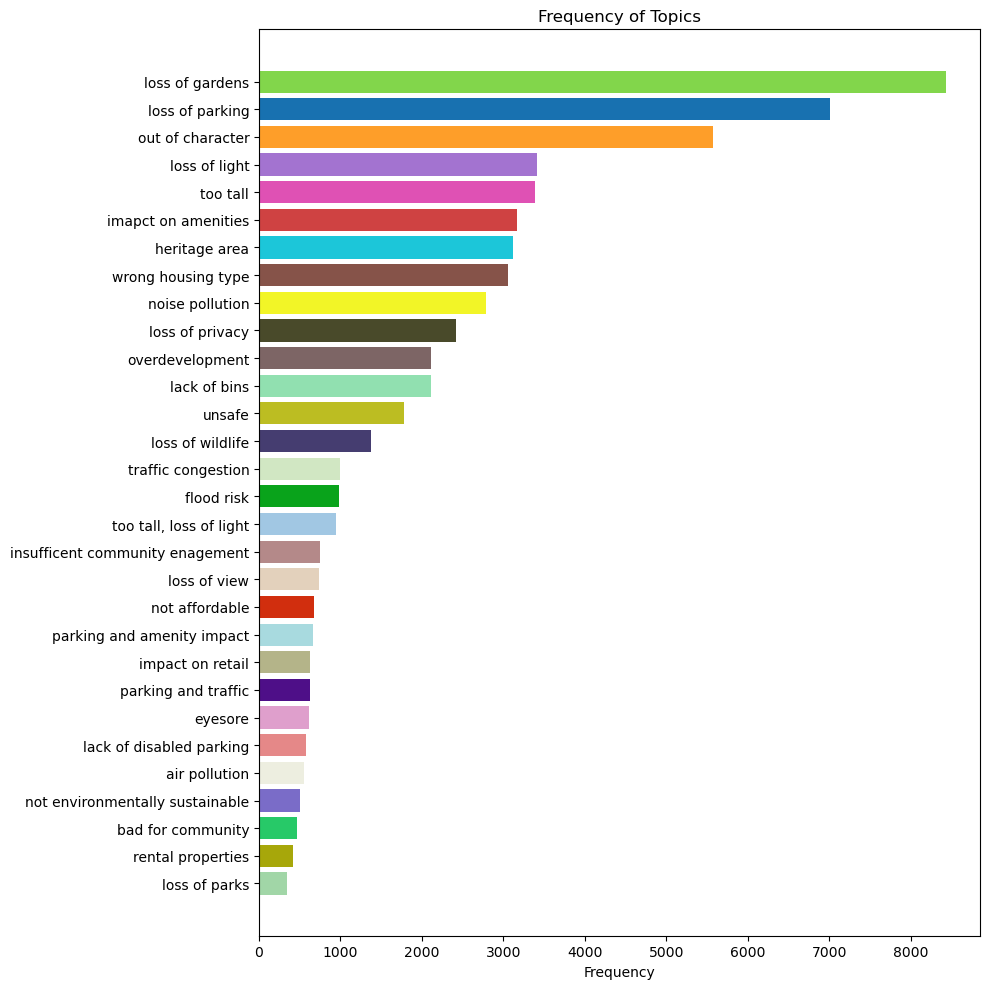

In [ ]:
# Keep only topics with count > 0 and that exist in filtered_topic_dict
topic_counts = {k: v for k, v in topic_counts.items() if v > 0 and k in filtered_topic_dict}

# Sort by frequency (descending)
topic_counts = dict(sorted(topic_counts.items(), key=lambda x: x[1], reverse=True))

# Convert to parallel lists for plotting (categorical x-axis)
x_labels = [filtered_topic_dict[k] for k in topic_counts.keys()]
y_values = list(topic_counts.values())

bar_colors = [color_map[topic] for topic in x_labels]

plt.figure(figsize=(10, 10))
plt.barh(new_x_labels, y_values, color=bar_colors)

plt.gca().invert_yaxis()
plt.xlabel('Frequency')
plt.title('Frequency of Topics')

plt.tight_layout()
plt.savefig('../results/figures/object_topics_frequency.png', dpi=500)
plt.show()

## Match and merge topics to comments 

In [17]:
cs_df = cs.read_all()

merged_df = pd.merge(cs_df, tp_df[['comment_id', 'topic_number_updated', 'probability_updated']], on='comment_id', how='left')

In [18]:
merged_df.head()

,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score,topic_number_updated,probability_updated
0,79910,Brent,23/2303_10,23/2303,"49 St Gabriels Road, London, NW2 4DT",Objects,2023-09-14,The proposed house is out of keeping with the ...,2025-04-08,51.474668,-0.105307,The proposed house is out of keeping with the ...,E09000022,-0.309787,"[8, 1]","[1.0, 0.05418749496189343]"
1,79913,Brent,23/2303_13,23/2303,"45 St Gabriels Road, London, NW2 4DT",Objects,2023-09-12,If the council's planning department allows th...,2025-04-08,51.474668,-0.105307,If the council's planning department allows th...,E09000022,-0.508164,"[8, 1]","[0.37246280287379435, 1.0]"
2,74170,Ealing,225185FUL_132,225185FUL,4 Marlborough Road Ealing LONDON W5 5NY W5 5NY,Objects,2023-01-22,The current house at no6 is a major feature of...,2025-04-07,51.505460,-0.301420,The current house at is a major feature of . I...,E09000009,-0.343599,"[8, 3, 12, 1, 4, 2, 30, 20, 14]","[1.0708997949518375, 0.08263818047530608, 0.32..."
3,89490,Ealing,212170FUL_56,212170FUL,29 Park Place Ealing W5 5NQ W5 5NQ,Objects,2021-09-29,I strongly object to this revised proposal. Co...,2025-04-10,51.508277,-0.303380,I strongly object to this revised proposal. Co...,E09000009,-0.572075,"[5, 12, 8, 15]","[0.7690144725100555, 1.0, 0.5138415758376459, ..."
4,89502,Ealing,212170FUL_68,212170FUL,33 Park Place LONDON W5 5NQ W5 5NQ,Objects,2021-09-27,Inappropriate development on a site which is n...,2025-04-10,51.508277,-0.303380,Inappropriate development on a site which is n...,E09000009,-0.629649,[1],[0.2054877548950345]


In [19]:
# make sure 'topic_number_updated' and 'probability_updated' are lists
merged_df['topic_number_updated'] = merged_df['topic_number_updated'].apply(lambda x: x if isinstance(x, list) else [])
merged_df['probability_updated'] = merged_df['probability_updated'].apply(lambda x: x if isinstance(x, list) else [])

# make sure 'topic_number_updated' are integers
merged_df['topic_number_updated'] = merged_df['topic_number_updated'].apply(lambda lst: [int(i) for i in lst])

# replace 'City Of London' with 'City of London' in council names
merged_df['council'] = merged_df['council'].replace('City Of London', 'City of London')

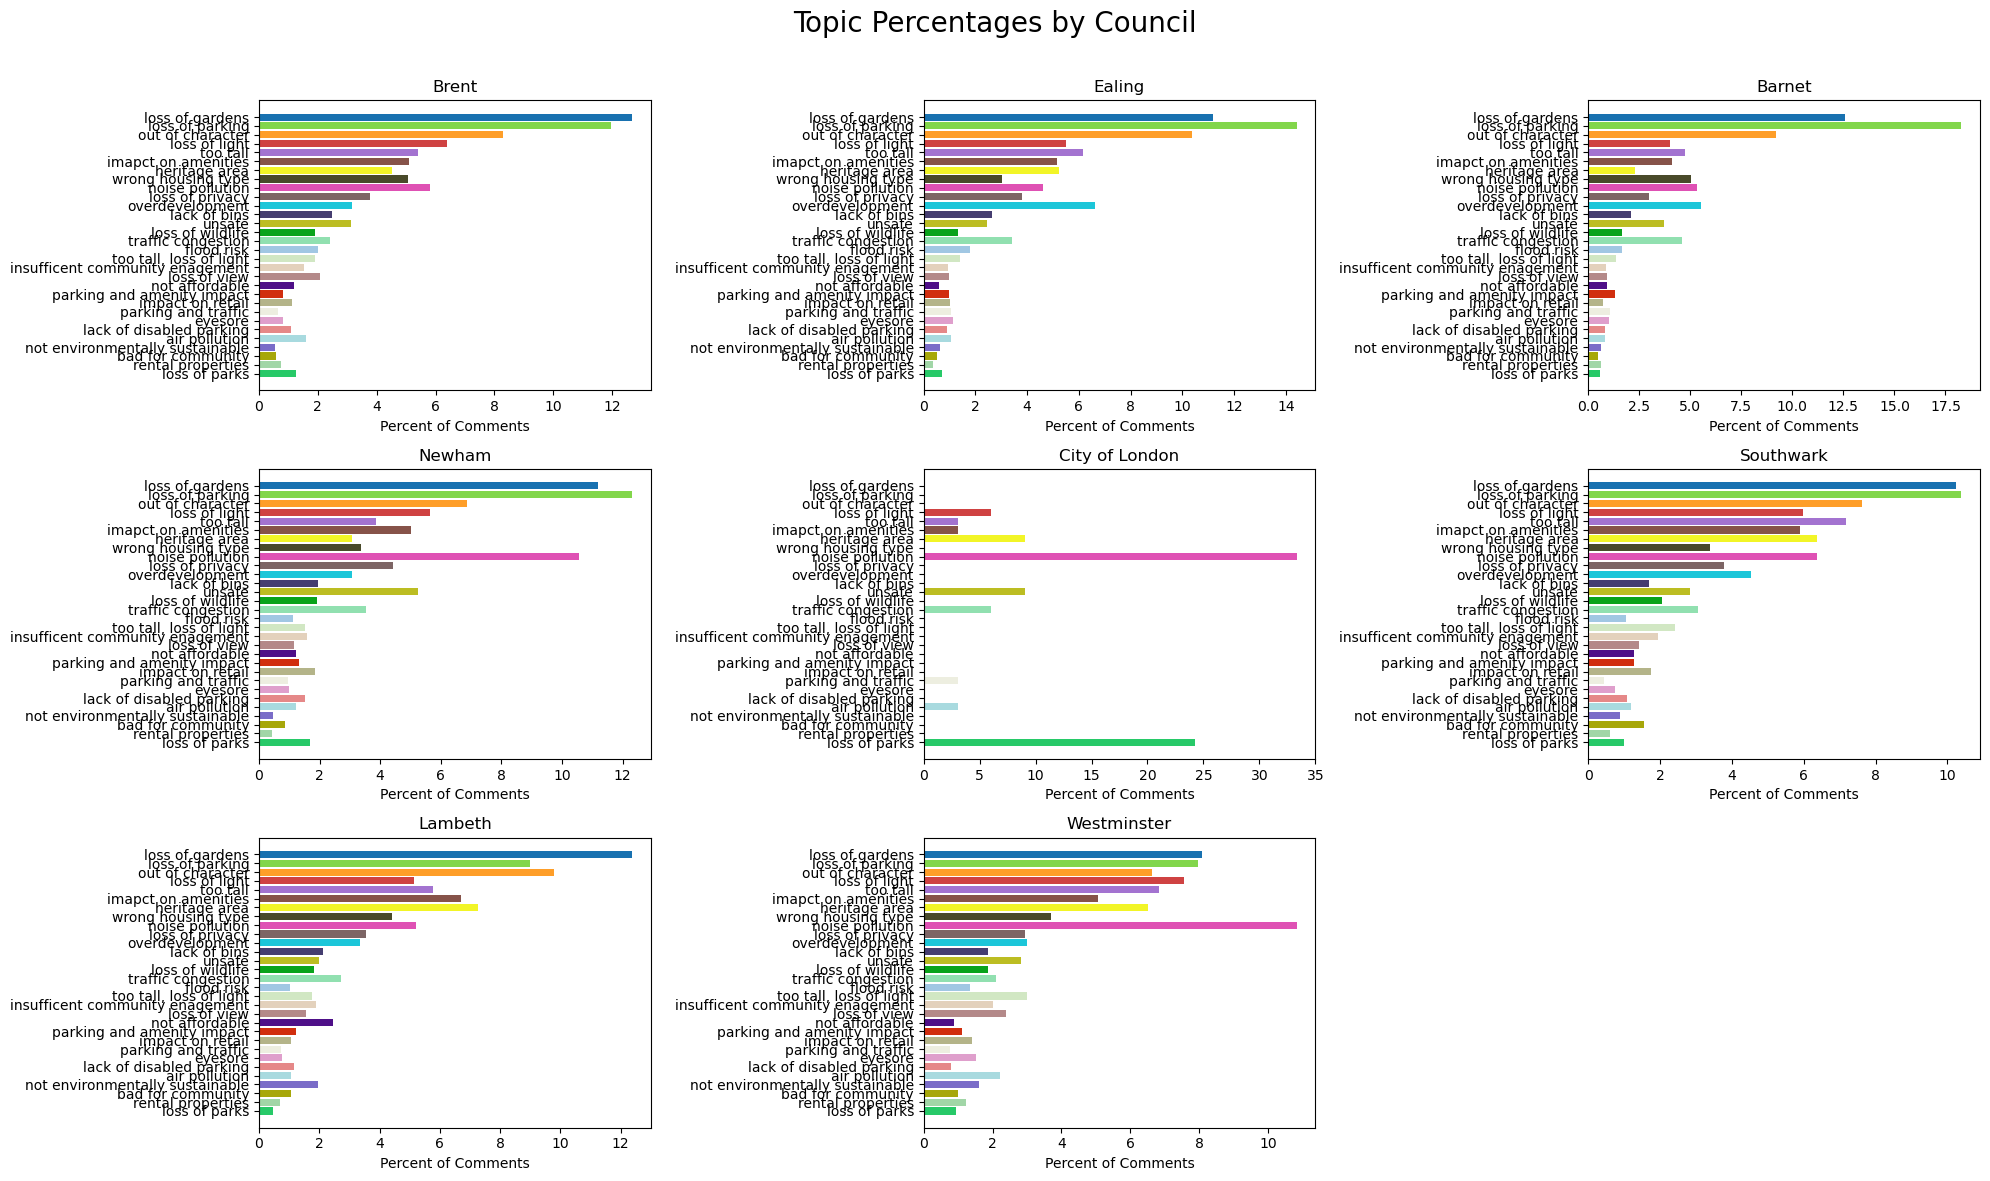

In [20]:
councils = merged_df['council'].unique()

# Ordered topic IDs (numeric keys)
ordered_topic_ids = list(filtered_topic_dict.keys())

# Color map keyed by topic ID
color_map = {
    topic_id: custom_hex_colors[i % len(custom_hex_colors)]
    for i, topic_id in enumerate(ordered_topic_ids)
}

# Create subplot grid
num_councils = len(councils)
cols = 3
rows = math.ceil(num_councils / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

for ax, council in zip(axes, councils):
    council_df = merged_df[merged_df['council'] == council]

    # Flatten topics into a list of numeric IDs
    all_topics = [t for topics in council_df['topic_number_updated'] for t in topics]

    # Count frequencies
    topic_counts = Counter(all_topics)
    total_comments = sum(topic_counts.values())

    # Percent of total
    y_values = [
        (topic_counts.get(topic_id, 0) / total_comments) * 100 if total_comments > 0 else 0
        for topic_id in ordered_topic_ids
    ]

    x_labels = [filtered_topic_dict[tid] for tid in ordered_topic_ids]
    bar_colors = [color_map[tid] for tid in ordered_topic_ids]

    ax.barh(new_x_labels, y_values, color=bar_colors)
    ax.set_title(council)
    ax.invert_yaxis()
    ax.set_xlabel('Percent of Comments')

# Hide any empty subplot panels
for i in range(len(councils), len(axes)):
    fig.delaxes(axes[i])

fig.suptitle('Topic Percentages by Council', fontsize=20)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


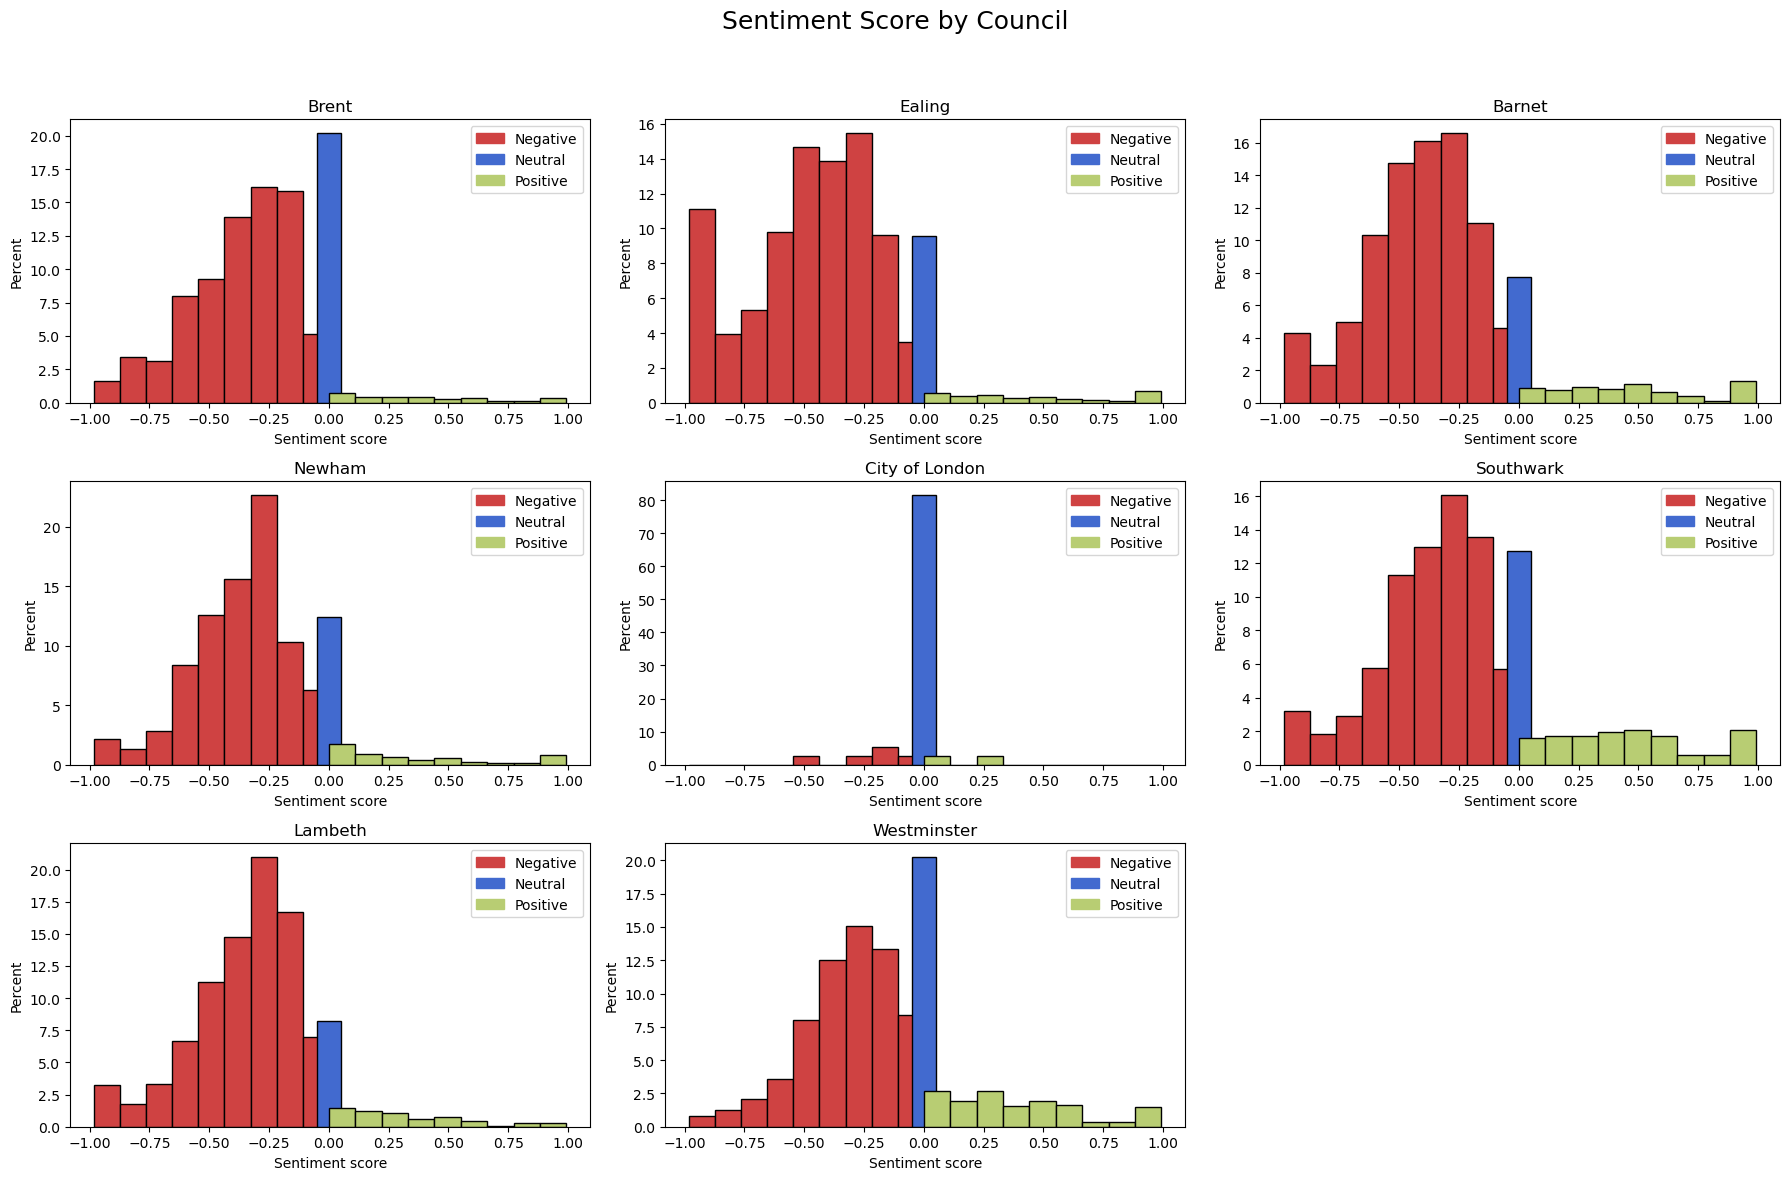

In [ ]:
councils = merged_df['council'].unique()

cols = 3
rows = math.ceil(len(councils) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*4))
axes = axes.flatten()

neg_bins = np.linspace(merged_df['sentiment_score'].min(), -0.0001, 10)
pos_bins = np.linspace(0.0001, merged_df['sentiment_score'].max(), 10)

for ax, council in zip(axes, councils):
    council_df = merged_df[merged_df['council'] == council]
    scores = council_df['sentiment_score'].dropna()
    total = len(scores)

    zeros = (scores == 0).sum()
    neg_scores = scores[scores < 0]
    pos_scores = scores[scores > 0]

    # Histogram for negative and positive values
    neg_counts, neg_edges = np.histogram(neg_scores, bins=neg_bins)
    pos_counts, pos_edges = np.histogram(pos_scores, bins=pos_bins)

    neg_perc = neg_counts / total * 100
    pos_perc = pos_counts / total * 100
    zero_perc = zeros / total * 100

    # Plot negative bins (red)
    ax.bar(neg_edges[:-1], neg_perc, width=np.diff(neg_edges), color="#cf4242", edgecolor='black', align='edge')

    # Plot zero bin (blue)
    if zero_perc > 0:
        ax.bar(0, zero_perc, width=0.1, color="#426acf", edgecolor='black', align='center')

    # Plot positive bins (green)
    ax.bar(pos_edges[:-1], pos_perc, width=np.diff(pos_edges), color="#b8cd73", edgecolor='black', align='edge')

    ax.set_title(council)
    ax.set_xlabel('Sentiment score')
    ax.set_ylabel('Percent')

    # Add a nice legend using Patch handles
    handles = [
        mpatches.Patch(color="#cf4242", label='Negative'),
        mpatches.Patch(color="#426acf", label='Neutral'),
        mpatches.Patch(color="#b8cd73", label='Positive')
    ]
    ax.legend(handles=handles, loc='upper right')

# Hide unused axes
for i in range(len(councils), len(axes)):
    fig.delaxes(axes[i])

fig.suptitle('Sentiment Score by Council', fontsize=18)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [2]:
esf.check_connection()

Connected to Elastic Search


In [5]:
esf_df = esf.res_units_x_query(min_res_units=1, since_year="01/01/2021", to_year="now")

In [7]:
prep.format_df(esf_df)

,lpa_name,uprn,actual_completion_date,decision,pp_id,wgs84_polygon.coordinates,wgs84_polygon.type,affordable_housing_fast_track,total_no_proposed_residential_units_shared_equity,total_no_proposed_residential_units_london_living_rent,...,site_number,status,polygon.geometries,polygon.type,wgs84_polygon,site_area,polygon.coordinates,total_no_affordable_units,polygon.crs.type,polygon.crs.properties.name
0,Haringey,100021221922,NaT,None,PP-13292547,"[[[-0.163738, 51.574545], [-0.163739, 51.57451...",Polygon,False,0,0,...,None,Application Under Consideration,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Greenwich,100021014360,NaT,None,PP-13747531,"[[[0.0824158, 51.4845463], [0.0825110999999999...",Polygon,False,0,0,...,None,Application Under Consideration,"[{'coordinates': [[[544686.95, 178232.8], [544...",GeometryCollection,NaN,NaN,NaN,NaN,NaN,NaN
2,Hounslow,None,NaT,None,PP-13731978,"[[[-0.244991, 51.497727], [-0.245034, 51.49761...",Polygon,NaN,0,0,...,None,Application Received,"[{'coordinates': [[[521921.96951210545, 179102...",geometrycollection,NaN,NaN,NaN,NaN,NaN,NaN
3,Greenwich,100020988708,NaT,None,PP-13833559,NaN,NaN,False,0,0,...,None,Application Under Consideration,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Islington,5300066661,NaT,None,PP-13739548,"[[[-0.084176, 51.551896], [-0.084177, 51.55186...",Polygon,NaN,0,0,...,31,Called in by Secretary of State,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28786,Havering,100021371875,NaT,Refused,13919886,"[[[0.1892237, 51.5773799], [0.1893301, 51.5772...",Polygon,False,0,0,...,None,Appeal Received,"[{'coordinates': [[[551793.45, 188771.95], [55...",GeometryCollection,NaN,NaN,NaN,NaN,NaN,NaN
28787,Tower Hamlets,6012785,2024-06-11,Approved,PP-12990830,"[[[-0.069244, 51.515501], [-0.069245, 51.51547...",Polygon,False,0,0,...,None,Completed,NaN,geometrycollection,NaN,NaN,NaN,NaN,NaN,NaN
28788,Brent,202044563,NaT,Approved,PP-11167792,NaN,NaN,False,0,0,...,None,Commenced,NaN,Polygon,NaN,NaN,"[[[523314.05, 184242.05], [523319.7, 184233.9]...",NaN,NaN,NaN
28789,Brent,202196424,2023-08-10,Approved,PP-12176298,NaN,NaN,None,0,0,...,None,Completed,NaN,Polygon,NaN,0.034,"[[[521252, 184175.25], [521251.05, 184173.35],...",NaN,NaN,NaN


## Alternative approach to selecting topics 

In [21]:
tp_df

,id,comment_id,topic_number,probability,add_date,topic_number_updated,probability_updated
0,1,230384FUL_16,[],[],2025-10-21,[],[]
1,2,21/3676/FUL_537,"[16, 0, 7]","[0.9496124818197162, 1.0, 0.532771282582039]",2025-10-21,[2],[0.532771282582039]
2,3,21/03147/FUL_6,"[19, 0, 25]","[0.7651527090417625, 0.5496195083521116, 0.155...",2025-10-21,"[19, 13]","[0.7651527090417625, 0.1552818674969217]"
3,4,230384FUL_22,[47],[1.0],2025-10-21,[2],[1.0]
4,5,230384FUL_15,[2],[1.0],2025-10-21,[2],[1.0]
...,...,...,...,...,...,...,...
30325,30326,24/AP/2313_9,[37],[1.0],2025-10-21,[37],[1.0]
30326,30327,241267FUL_81,[35],[1.0],2025-10-21,[8],[1.0]
30327,30328,24/AP/2313_15,"[87, 44, 71, 72]","[0.13251934256196757, 0.0777459370777266, 0.07...",2025-10-21,[44],[0.0777459370777266]
30328,30329,24/AP/2313_17,"[25, 26]","[1.0, 0.7320134997496925]",2025-10-21,"[13, 26]","[1.0, 0.7320134997496925]"


In [22]:
# function that only keeps topics in tp_df where probability >0.5 and frequency in the dataframe above 50 

def filter_topics(tp_df, min_prob=0.5, min_freq=50):
    # Count frequencies of all topics
    all_topics = [t for topics in tp_df['topic_number'] for t in topics]
    topic_freq = Counter(all_topics)
    
    # Filter topics based on min_prob and min_freq
    filtered_topic_numbers = []
    filtered_probabilities = []
    
    for i in range(len(tp_df)):
        topics = tp_df.at[i, 'topic_number']
        probs = tp_df.at[i, 'probability']
        
        filtered_topics = []
        filtered_probs = []
        
        for t, p in zip(topics, probs):
            if p >= min_prob and topic_freq[t] >= min_freq:
                filtered_topics.append(t)
                filtered_probs.append(p)
        
        filtered_topic_numbers.append(filtered_topics)
        filtered_probabilities.append(filtered_probs)
    
    tp_df['filtered_topic_number'] = filtered_topic_numbers
    tp_df['filtered_probability'] = filtered_probabilities
    
    return tp_df

In [23]:
new_tp_df = filter_topics(tp_df, min_prob=0.5, min_freq=50)


In [24]:
new_tp_df

,id,comment_id,topic_number,probability,add_date,topic_number_updated,probability_updated,filtered_topic_number,filtered_probability
0,1,230384FUL_16,[],[],2025-10-21,[],[],[],[]
1,2,21/3676/FUL_537,"[16, 0, 7]","[0.9496124818197162, 1.0, 0.532771282582039]",2025-10-21,[2],[0.532771282582039],"[16, 0, 7]","[0.9496124818197162, 1.0, 0.532771282582039]"
2,3,21/03147/FUL_6,"[19, 0, 25]","[0.7651527090417625, 0.5496195083521116, 0.155...",2025-10-21,"[19, 13]","[0.7651527090417625, 0.1552818674969217]","[19, 0]","[0.7651527090417625, 0.5496195083521116]"
3,4,230384FUL_22,[47],[1.0],2025-10-21,[2],[1.0],[47],[1.0]
4,5,230384FUL_15,[2],[1.0],2025-10-21,[2],[1.0],[2],[1.0]
...,...,...,...,...,...,...,...,...,...
30325,30326,24/AP/2313_9,[37],[1.0],2025-10-21,[37],[1.0],[37],[1.0]
30326,30327,241267FUL_81,[35],[1.0],2025-10-21,[8],[1.0],[35],[1.0]
30327,30328,24/AP/2313_15,"[87, 44, 71, 72]","[0.13251934256196757, 0.0777459370777266, 0.07...",2025-10-21,[44],[0.0777459370777266],[],[]
30328,30329,24/AP/2313_17,"[25, 26]","[1.0, 0.7320134997496925]",2025-10-21,"[13, 26]","[1.0, 0.7320134997496925]","[25, 26]","[1.0, 0.7320134997496925]"


In [25]:
unique_topics = set()
for topics in tp_df['filtered_topic_number']:
    unique_topics.update(topics)

len(unique_topics)

95

## Plot the topic embedding for the documents 

In [26]:
custom_hex_colors = [
    "#1871b0", "#82d64b", "#fe9e29", "#cf4242", "#a373d0",
    "#865349", "#F2F527", "#494A2A", "#df51b4", "#7d6565", 
    "#1cc6d9", "#453D70", "#bcbd22", "#09A31B", "#91e0b0",
    "#a1c7e3", "#d1e7c3", "#e3d1bc", "#b48989", "#4e0f88",
    "#D12E0E", "#B4B489", "#EDEEE0", "#df9fcc", "#e58888", 
    "#a8dadf", "#7A6CC8", "#A7A70A", "#A1D6A7", "#27c968"
]

In [27]:
sentence_model = SentenceTransformer("Bea-Taylor/objection_fine_tuned_4")
topic_model = BERTopic.load("../model_outputs/topic_model/bertopic_less_topics/full_model/object_model", embedding_model=sentence_model)

In [28]:
# Load the comments from the database
df = cs.read_all()

df_objects = df[df['stance']=='Objects']

### Preprocess the text data

# split text on newlines, this function preserves the metadata by exploding the dataframe
df_objects_split = nlp_tasks.split_text_on_newline(df=df_objects, column='cleaned_comment_text')

print(f'\n Length after splitting data')
print('Objects:', len(df_objects_split))

# split the text by chunks of a maximum length, this function preserves the metadata by exploding the dataframe

max_length_tokens = sentence_model.get_max_seq_length()

df_objects_split = nlp_tasks.split_text_by_length(df=df_objects_split, column='cleaned_comment_text', max_length=max_length_tokens, overlap=40, filter_empty=False, filter_short=False)

print(f'\n Length after chunking data')
print('Objects:', len(df_objects_split))

cleaned_object_text = df_objects_split['cleaned_comment_text'].tolist()

Token indices sequence length is longer than the specified maximum sequence length for this model (345 > 256). Running this sequence through the model will result in indexing errors



 Length after splitting data
Objects: 140946

 Length after chunking data
Objects: 141965


In [29]:
embeddings = sentence_model.encode(cleaned_object_text, show_progress_bar=True)
reduced_embeddings = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric='cosine').fit_transform(embeddings)

Batches: 100%|██████████| 4437/4437 [07:31<00:00,  9.83it/s]  


In [30]:
topics = topic_model.get_document_info(cleaned_object_text)['Topic'].to_numpy()

Number of unique topics to plot: 30


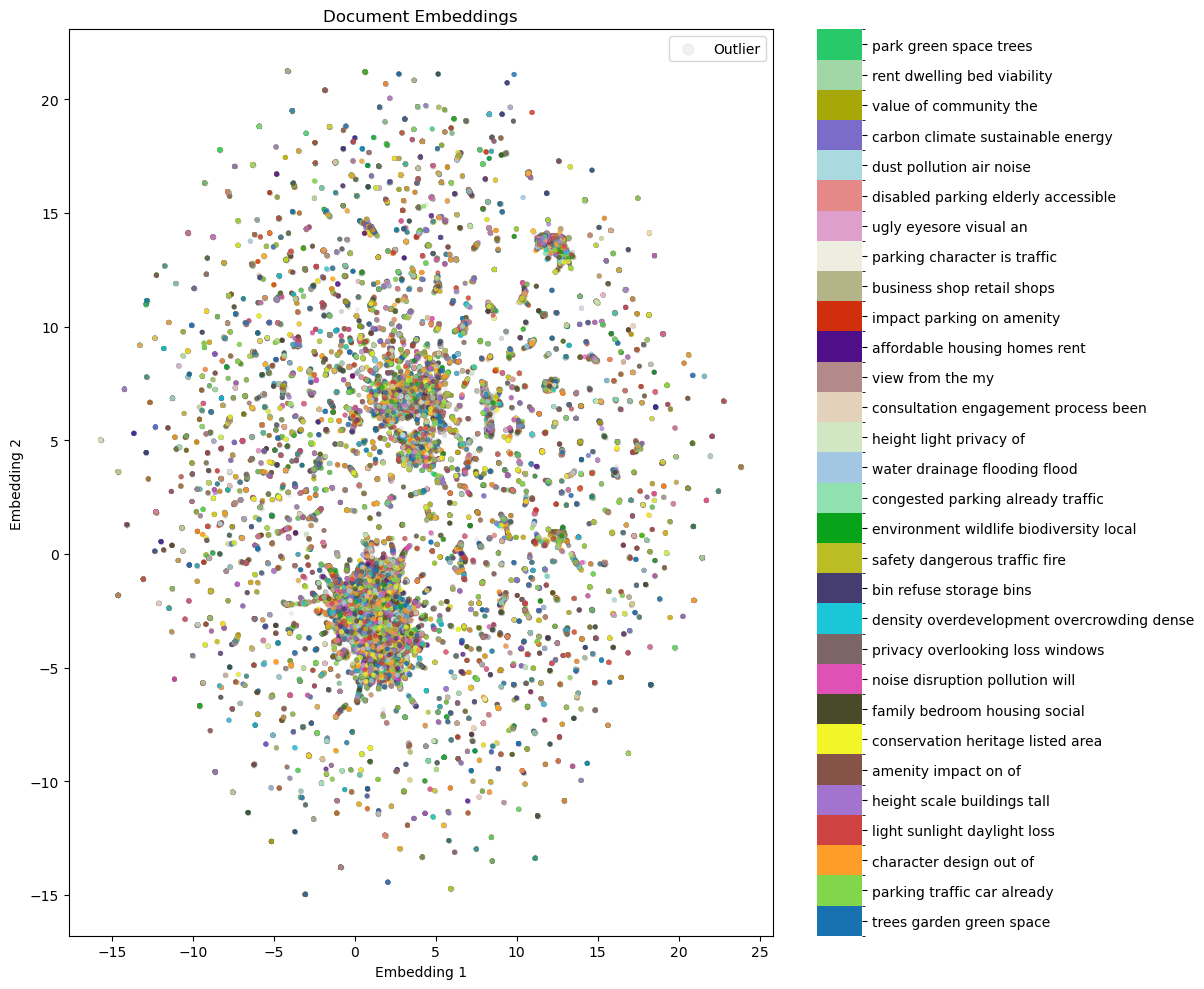

In [31]:
# --- build reduced topic list ---
unique_topics = set()
for topic_list in tp_df['topic_number_updated']:
    unique_topics.update(topic_list)
unique_topics = sorted(unique_topics)

n_topics = len(unique_topics)

print(f'Number of unique topics to plot: {n_topics}')

# --- color palette ---
colors_for_topics = [custom_hex_colors[i % len(custom_hex_colors)] for i in range(n_topics)]
cmap = ListedColormap(colors_for_topics)
norm = BoundaryNorm(boundaries=np.arange(-0.5, n_topics + 0.5, 1), ncolors=n_topics)

# --- figure and axis ---
fig, ax = plt.subplots(figsize=(12, 10))

# ensure boolean masks are proper boolean NumPy arrays
is_outlier = (topics == -1)
is_reduced_topic = np.array([t in unique_topics for t in topics], dtype=bool)

# --- Plot outliers (gray) ---
ax.scatter(
    reduced_embeddings[is_outlier, 0],
    reduced_embeddings[is_outlier, 1],
    color='lightgrey',
    s=7,
    alpha=0.3,
    label='Outlier'
)

# --- Plot other topics (not in reduced list) in gray ---
ax.scatter(
    reduced_embeddings[~is_outlier & ~is_reduced_topic, 0],
    reduced_embeddings[~is_outlier & ~is_reduced_topic, 1],
    color='lightgray',
    s=7,
    alpha=0.3
)

# --- Plot points in your reduced topic list (colored) ---
ax.scatter(
    reduced_embeddings[~is_outlier & is_reduced_topic, 0],
    reduced_embeddings[~is_outlier & is_reduced_topic, 1],
    c=[unique_topics.index(t) for t in topics[~is_outlier & is_reduced_topic]],
    cmap=cmap,
    norm=norm,
    s=7,
    alpha=0.6
)



# --- Labels and layout ---
ax.set_title('Document Embeddings')
ax.set_xlabel('Embedding 1')
ax.set_ylabel('Embedding 2')

# --- Discrete colorbar for selected topics only ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, ticks=np.arange(n_topics))
cbar.ax.set_yticklabels([filtered_topic_dict.get(t, f'Topic {t}') for t in unique_topics])
cbar.outline.set_visible(False)

ax.legend(markerscale=3)
plt.tight_layout()

plt.savefig('../results/figures/object_topics_scatter.png', dpi=500)
plt.show()